**random forest implementation**

import libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from termcolor import colored

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

print(colored("\n all libraries import succesfully", "blue"))


 all libraries import succesfully


**library configurations**

In [2]:
pd.options.mode.copy_on_write = True #rewrite on variable
sns.set_style("darkgrid") 
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None) #print all the column of dataframe 
pd.set_option("display.max_colwidth", None) #print all the data in a feature

print(colored('\nall libraries Configed succesfully.', 'blue'))


all libraries Configed succesfully.


**collecting data**

In [3]:
data = pd.read_csv('winequality-red.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**data information**

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
data.describe().T.style.background_gradient(axis = 0)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.000000,8.319637,1.741096,4.600000,7.100000,7.900000,9.200000,15.900000
volatile acidity,1599.000000,0.527821,0.179060,0.120000,0.390000,0.520000,0.640000,1.580000
citric acid,1599.000000,0.270976,0.194801,0.000000,0.090000,0.260000,0.420000,1.000000
residual sugar,1599.000000,2.538806,1.409928,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,1599.000000,0.087467,0.047065,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,1599.000000,15.874922,10.460157,1.000000,7.000000,14.000000,21.000000,72.000000
total sulfur dioxide,1599.000000,46.467792,32.895324,6.000000,22.000000,38.000000,62.000000,289.000000
density,1599.000000,0.996747,0.001887,0.990070,0.995600,0.996750,0.997835,1.003690
pH,1599.000000,3.311113,0.154386,2.740000,3.210000,3.310000,3.400000,4.010000
sulphates,1599.000000,0.658149,0.169507,0.330000,0.550000,0.620000,0.730000,2.000000


**data preprocessning**

In [6]:
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

**visualization and plots**

In [7]:
#rename the columns to better recall them

data.rename(columns = {
    "fixed acidity" :   "fixed_acidity",        
    "volatile acidity" : "volatile_acidity" ,       
    "citric acid" :     "citric_acid",       
    "residual sugar" :  "residual_sugar",          
    "free sulfur dioxide"  :  "free_sulfur_dioxide", 
    "total sulfur dioxide" :  "total_sulfur_dioxide"
}, inplace = True)

In [8]:
#create a list of DataFrame columns
columns = list(data.columns)
columns

['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

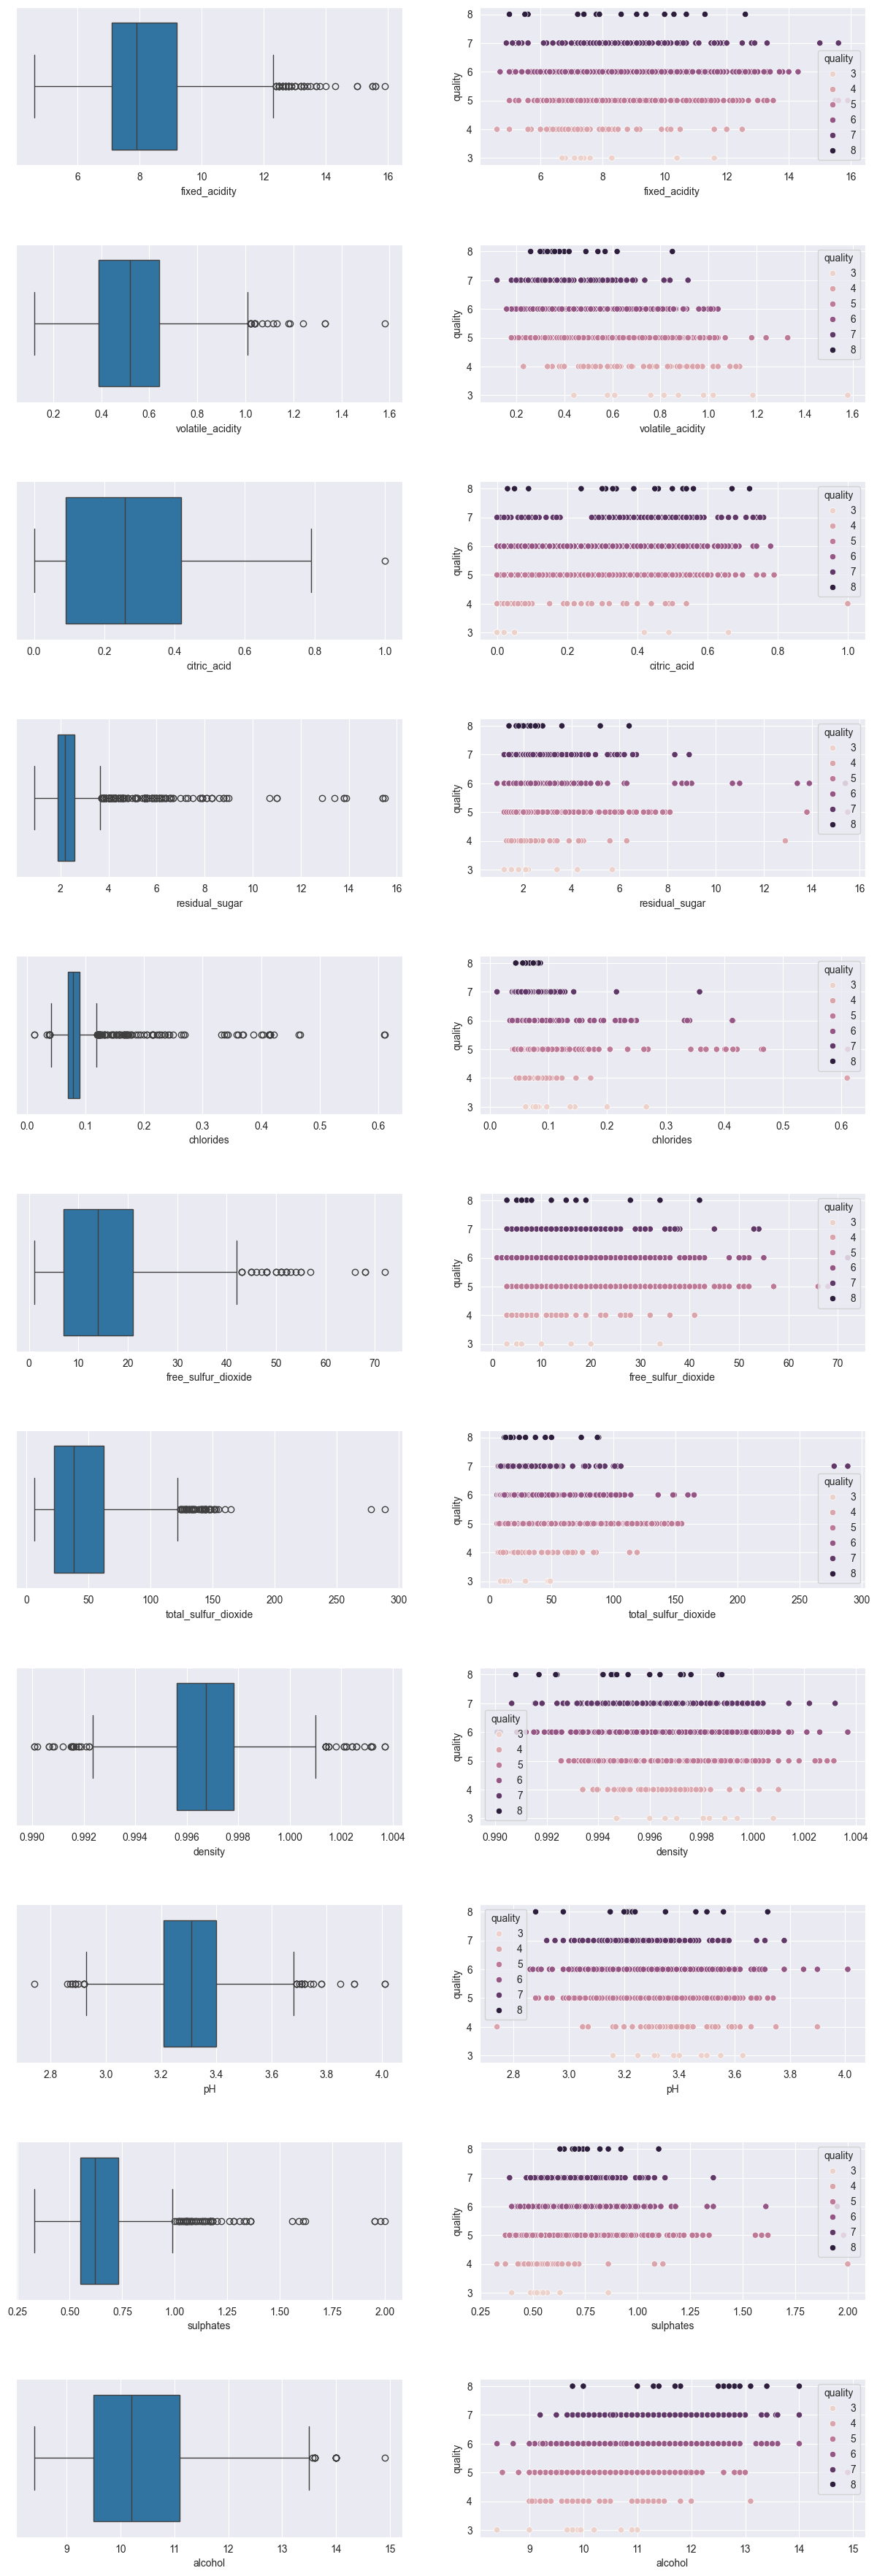

In [9]:
fig, ax = plt.subplots(11, 2, figsize = (15, 45))
plt.subplots_adjust(hspace = 0.5)
for i in range(11):
    #ax 1
    sns.boxplot(x = columns[i], data = data, ax=ax[i, 0])
    #ax 2
    sns.scatterplot(x = columns[i], y = "quality", data = data, hue = "quality", ax=ax[i, 1])

there is no outliear in data 

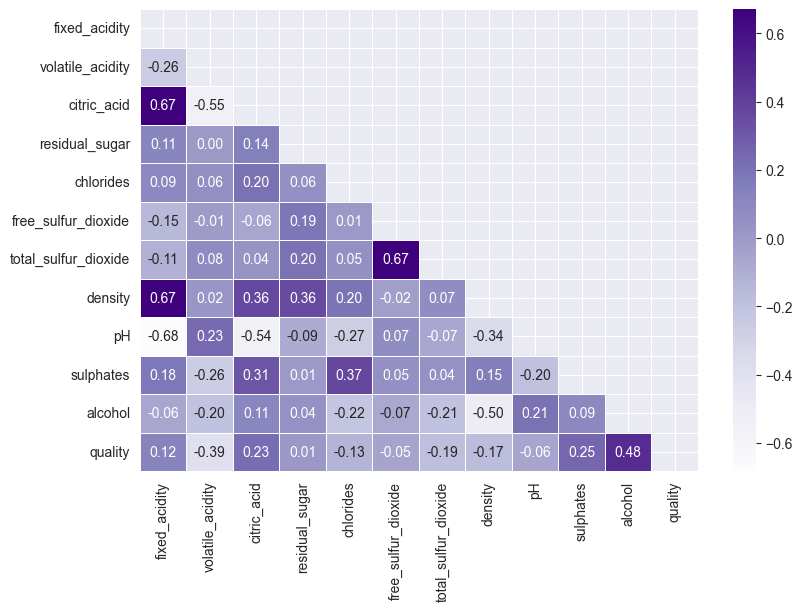

In [19]:
corr = data.corr()
plt.figure(figsize =(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', linewidth=0.5, cmap='Purples', mask=np.triu(corr))
plt.show()

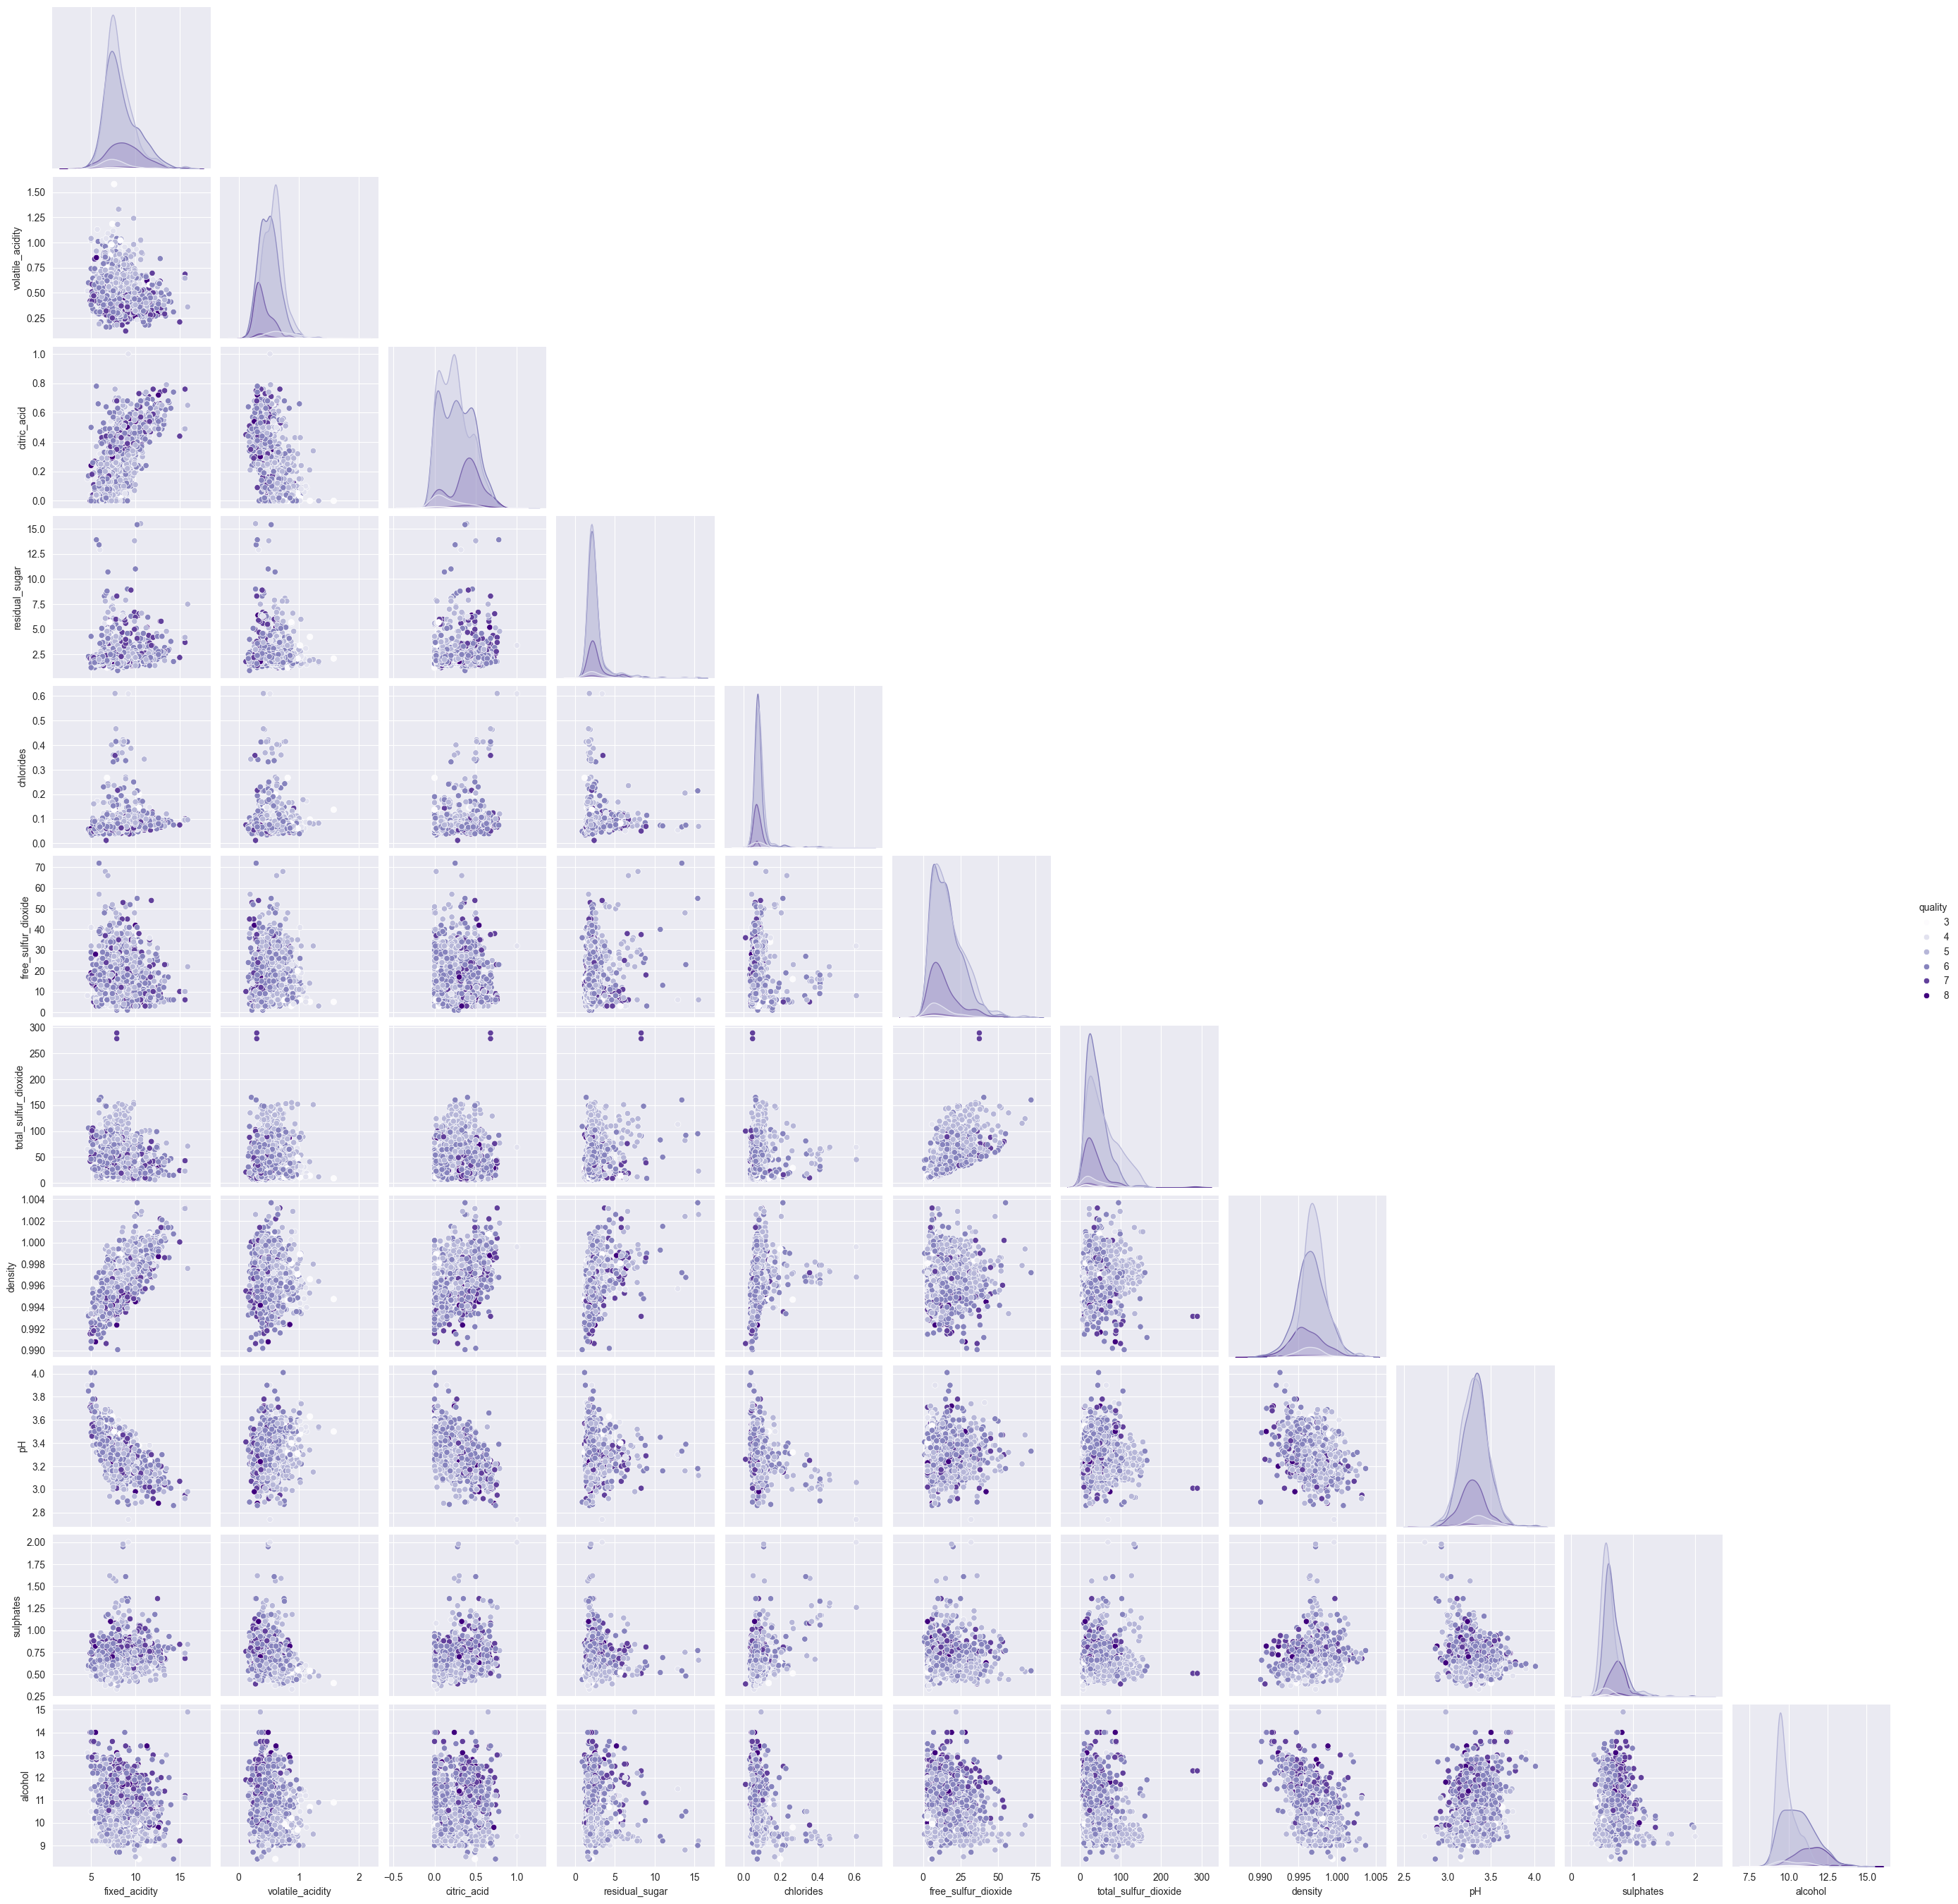

In [16]:
sns.pairplot(data, hue = "quality", corner = True, palette = "Purples")

**plots analysis**

best correlation between 
citeic_acid & flex_acidity ---> 0.67
density & flex_acidity ---> 0.67
total_sulfor_dioxide & free_sulfor_dioxide ---> 0.67

**target categorizing**

In [21]:
#quality classes
data.quality.unique()

array([5, 6, 7, 4, 8, 3])

In [27]:
#Replace values in quality column to Good and Middle and Bad
data = data.replace({'quality' : {
                                    8 : 'Good',
                                    7 : 'Good',
                                    6 : 'Middle',
                                    5 : 'Middle',
                                    4 : 'Bad',
                                    3 : 'Bad',
        }}
)

In [29]:
data["quality"]

0       Middle
1       Middle
2       Middle
3       Middle
4       Middle
         ...  
1594    Middle
1595    Middle
1596    Middle
1597    Middle
1598    Middle
Name: quality, Length: 1599, dtype: object

**normalization**

In [31]:
#create X from DataFrame and y as target
x_temp = data.drop(columns = "quality")
y = data.quality

Normalize X data to decrease effect of larg number.
Here, Using MinMaxScaler and ranged in [0, 1]

In [34]:
scaler = MinMaxScaler(feature_range = (0, 1)).fit_transform(x_temp)
x = pd.DataFrame(scaler, columns = x_temp.columns)
x.describe().T.style.background_gradient(axis = 0, cmap = "Purples")

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1599.000000,0.329171,0.154079,0.000000,0.221239,0.292035,0.407080,1.000000
volatile_acidity,1599.000000,0.279329,0.122644,0.000000,0.184932,0.273973,0.356164,1.000000
citric_acid,1599.000000,0.270976,0.194801,0.000000,0.090000,0.260000,0.420000,1.000000
residual_sugar,1599.000000,0.112247,0.096570,0.000000,0.068493,0.089041,0.116438,1.000000
chlorides,1599.000000,0.125988,0.078573,0.000000,0.096828,0.111853,0.130217,1.000000
free_sulfur_dioxide,1599.000000,0.209506,0.147326,0.000000,0.084507,0.183099,0.281690,1.000000
total_sulfur_dioxide,1599.000000,0.142996,0.116238,0.000000,0.056537,0.113074,0.197880,1.000000
density,1599.000000,0.490211,0.138571,0.000000,0.406021,0.490455,0.570117,1.000000
pH,1599.000000,0.449695,0.121564,0.000000,0.370079,0.448819,0.519685,1.000000
sulphates,1599.000000,0.196496,0.101501,0.000000,0.131737,0.173653,0.239521,1.000000


**modeling**

In [36]:
#define the function to ploting confusion matrix

def plot_confusion_matrix(y_test, y_prediction):
    #plotting confusion matrix
    cm = metrics.confusion_matrix(y_test, y_prediction)
    ax = plt.subplot()
    ax = sns.heatmap(cm, annot = True, fmt = "", cmap = "Purples")
    ax.set_xlabel("prediced labels", fontsize = 18)
    ax.label_ylabel("True label", fontsize = 18)
    ax.set_title("confusion matrix", fontsize = 25)
    ax.xaxis.set_thicklabels(["BAD", "GOOD", "MIDDLE"])
    ax.yaxis.set_thicklabels(["BAD", "GOOD", "MIDDLE"])
    plt.show()

In [37]:
#define the function to ploting classification report 

def clfr_plot(y_test, y_pred):
    '''plotting classification report'''
    cr = pd.DataFrame(metrics.classification_report(y_test, y_pred_rf, digits = 3,
    output_dict = True)).T

    cr.drop(columns = "support", inplace = True)
    sns.heatmap(cr, cmap = "Purples", annot = True, linecolor = "white", linewidths = 0.5).xaxis.tick_top()

In [38]:
def clf_plot(y_pred):
    """ 1. plotting confusion matrix
        2. plotting classification report """
    cm = metrics.confusion_matrix(y_test, y_pred)
    cr = pd.DataFrame(metrics.classification_report(y_test, y_pred, digits = 3, output_dict = True)).T
    cr.drop(columns = "support", inplace = True)
    fig, ax = plt.subplots(1, 2, figsize = (15,5))

    #left AX: confusion matrix
    ax[0] = sns.heatmap(cm, annot = True, fmt = "", cmap = "Purples", ax=ax[o])
    ax[0].set_xlabel("prediced labels", fontsize = 18)
    ax[0].label_ylabel("True label", fontsize = 18)
    ax[0].set_title("confusion matrix", fontsize = 25)
    ax[0].xaxis.set_thicklabels(["BAD", "GOOD", "MIDDLE"])

    #right AX: classification report 
    ax[1] = sns.heatmap(cm, annot = True, fmt = "", cmap = "Purples", linecolor = "white", linewidths = 0.5, ax=ax[1])
    ax[1].xaxis.tick_top()
    ax[1].set_title("classification report", fontsize = 25)
    plt.show()